# Project 05 — End-to-End GPU LoRA Training and Evaluation

This notebook turns Project 05 from a source-code demonstration into an **executed, evidence-backed portfolio experiment**.

It performs the complete workflow:

1. validates the NVIDIA GPU and software environment;
2. builds a 400+ example public-safe ML/Data Science instruction curriculum;
3. prevents paraphrase leakage by splitting at the topic-group level;
4. fine-tunes `google/flan-t5-small` with LoRA / PEFT;
5. evaluates the untouched base model and trained adapter on exactly the same held-out prompts;
6. calculates held-out loss, perplexity, BERTScore, ROUGE, semantic relevance, instruction adherence, latency, throughput, and transparent hallucination-risk flags;
7. generates paired bootstrap confidence intervals, category-level analysis, plots, examples, and a manual-review template;
8. saves all results directly into JSON, CSV, Markdown, and PNG files under `outputs/`;
9. prepares the adapter and metrics for GitHub and Hugging Face publication.

> **Important:** automated generation metrics are not factuality guarantees. Complete the manual review template before making final quality claims.

## 1. Locate the project and optionally install dependencies

Open this notebook from either the project root or the `notebooks/` folder. Set `INSTALL_DEPENDENCIES = True` for the first run in a new environment. Restart the kernel after installation if PyTorch or CUDA packages were changed.

In [2]:
from pathlib import Path
import os
import subprocess
import sys


def find_project_dir() -> Path:
    start = Path.cwd().resolve()
    candidates = [
        start,
        start.parent,
        start / "05-instruction-tuned-domain-llm",
    ]

    for candidate in candidates:
        config_path = candidate / "configs" / "portfolio_experiment.yaml"
        if config_path.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate 05-instruction-tuned-domain-llm. "
        "Open Jupyter from the project root or notebooks folder."
    )


PROJECT_DIR = find_project_dir()
os.chdir(PROJECT_DIR)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "-r",
            "requirements-training.txt",
        ],
        check=True,
    )

print("Project directory:", PROJECT_DIR)
print("Python executable:", sys.executable)

Project directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm
Python executable: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\.venv\Scripts\python.exe


## 2. Verify the RTX GPU and reproducibility settings

The notebook uses BF16 when supported, otherwise FP16, and falls back to FP32. CUDA availability must be `True` for the fast local-GPU workflow.

In [4]:
from pprint import pprint

from src.experiment_utils import choose_precision, hardware_info, save_json, set_reproducibility

SEED = 42
set_reproducibility(SEED, deterministic=False)
HARDWARE = hardware_info()
PRECISION = choose_precision('auto')
pprint(HARDWARE)
pprint(PRECISION)

save_json(HARDWARE, PROJECT_DIR / 'outputs' / 'hardware_environment.json')

if not HARDWARE.get('cuda_available'):
    raise RuntimeError(
        'PyTorch cannot see an NVIDIA GPU. Install a CUDA-enabled PyTorch build before training. '
        'The notebook intentionally stops here so a long CPU training run is not started accidentally.'
    )

{'accelerate': '1.14.0',
 'bf16_supported': True,
 'compute_capability': [12, 0],
 'cuda_available': True,
 'cuda_runtime': '13.2',
 'datasets': '4.8.5',
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'gpu_vram_gb': 31.84,
 'peft': '0.20.0',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 198 Stepping 2, GenuineIntel',
 'python': '3.13.14',
 'sentence_transformers': '5.6.1',
 'tf32_supported': True,
 'torch': '2.12.1+cu132',
 'transformers': '5.14.1'}
{'bf16': True, 'fp16': False, 'mode': 'bf16', 'tf32': True}


## 3. Build the expanded instruction dataset

The extended curriculum combines the original 82 examples with a larger curated knowledge bank. Multiple prompt styles for the same concept stay in the same split, preventing paraphrase leakage from inflating test results.

In [5]:
import json
from scripts.build_extended_dataset import build_dataset

DATASET_RESULT = build_dataset(
    PROJECT_DIR / 'data' / 'ml_ds_instruction_dataset.jsonl',
    PROJECT_DIR / 'data' / 'ml_ds_instruction_dataset_extended.jsonl',
    PROJECT_DIR / 'data' / 'evaluation_prompts_extended.jsonl',
    PROJECT_DIR / 'outputs' / 'extended_dataset_statistics.json',
    PROJECT_DIR / 'outputs' / 'extended_dataset_validation_report.json',
)

print(json.dumps(DATASET_RESULT['statistics'], indent=2))
print('Validation:', DATASET_RESULT['validation']['valid'])

{
  "rows": 401,
  "topic_groups": 203,
  "unique_topics": 205,
  "categories": {
    "algorithm_comparison": 32,
    "code_example": 12,
    "concept_explanation": 93,
    "example_generation": 83,
    "interview_answer": 83,
    "metric_explanation": 48,
    "quality_analytics": 17,
    "responsible_ai": 12,
    "workflow_explanation": 21
  },
  "difficulties": {
    "advanced": 27,
    "beginner": 115,
    "intermediate": 259
  },
  "splits": {
    "test": 36,
    "train": 323,
    "validation": 42
  },
  "average_prompt_words": 7.79,
  "average_response_words": 43.84,
  "min_response_words": 21,
  "max_response_words": 94,
  "source": "self-authored and curated public-safe ML/DS curriculum",
  "split_policy": "topic-grouped deterministic 80/10/10 split"
}
Validation: True


## 4. Inspect dataset quality and split isolation

,rows,categories,topics,topic_groups,splits,average_prompt_words,average_response_words,min_response_words,max_response_words
0,401,"{'algorithm_comparison': 32, 'code_example': 1...",205,203,"{'test': 36, 'train': 323, 'validation': 42}",7.79,43.84,21,94


split,test,train,validation
category,,,
algorithm_comparison,2,26,4
code_example,1,7,4
concept_explanation,9,76,8
example_generation,7,67,9
interview_answer,7,67,9
metric_explanation,4,39,5
quality_analytics,2,13,2
responsible_ai,1,11,0
workflow_explanation,3,17,1


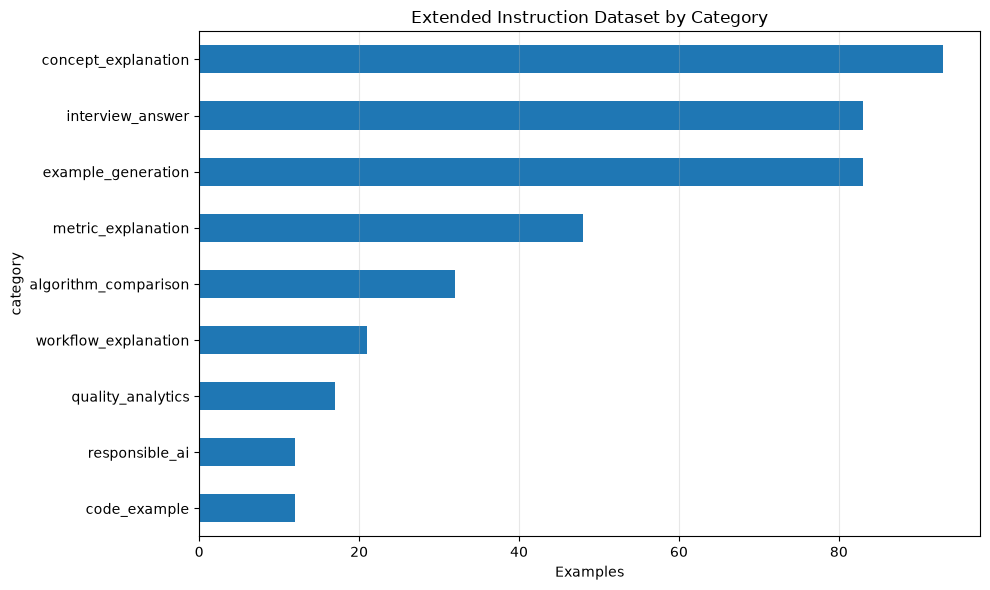

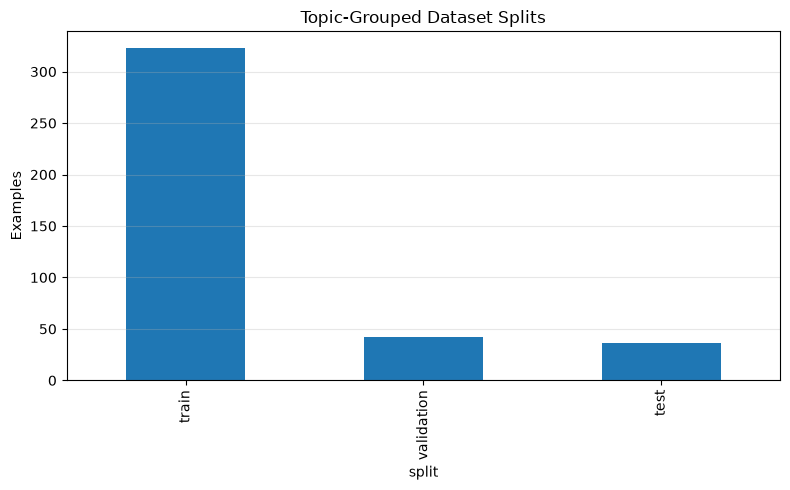

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_preprocessing import dataset_statistics, load_jsonl, validate_records

rows = load_jsonl(PROJECT_DIR / 'data' / 'ml_ds_instruction_dataset_extended.jsonl')
dataset_df = pd.DataFrame(rows)
validation = validate_records(rows, enforce_group_isolation=True)
assert validation['valid'], validation['issues'][:10]

stats = dataset_statistics(rows)
display(pd.DataFrame([stats]))
display(pd.crosstab(dataset_df['category'], dataset_df['split']))

fig, ax = plt.subplots(figsize=(10, 6))
dataset_df['category'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Extended Instruction Dataset by Category')
ax.set_xlabel('Examples')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_DIR / 'outputs' / 'extended_instruction_category_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
dataset_df['split'].value_counts().reindex(['train', 'validation', 'test']).plot(kind='bar', ax=ax)
ax.set_title('Topic-Grouped Dataset Splits')
ax.set_ylabel('Examples')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_DIR / 'outputs' / 'extended_dataset_split_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Create a hardware-adjusted runtime configuration

The default profile uses FLAN-T5-small, LoRA rank 16, and an effective batch size of 16. This model remains practical for the later quantized ONNX browser deployment.

The cell automatically reduces the micro-batch size on lower-VRAM RTX cards. You may increase it after a successful first run.

In [7]:
import copy
import yaml

BASE_CONFIG_PATH = PROJECT_DIR / 'configs' / 'portfolio_experiment.yaml'
RUNTIME_CONFIG_PATH = PROJECT_DIR / 'configs' / 'portfolio_experiment_runtime.yaml'
config = yaml.safe_load(BASE_CONFIG_PATH.read_text(encoding='utf-8'))

vram = float(HARDWARE.get('gpu_vram_gb') or 0)
if vram >= 16:
    micro_batch, grad_accum, eval_batch = 8, 2, 16
elif vram >= 8:
    micro_batch, grad_accum, eval_batch = 4, 4, 8
else:
    micro_batch, grad_accum, eval_batch = 2, 8, 4

config['training']['train_batch_size'] = micro_batch
config['training']['gradient_accumulation_steps'] = grad_accum
config['training']['eval_batch_size'] = eval_batch
config['training']['precision'] = PRECISION['mode']
config['experiment']['run_id'] = None

RUNTIME_CONFIG_PATH.write_text(yaml.safe_dump(config, sort_keys=False), encoding='utf-8')
print(RUNTIME_CONFIG_PATH.read_text(encoding='utf-8'))
print('Effective train batch size:', micro_batch * grad_accum)

experiment:
  name: project-05-portfolio-scale-lora
  run_id: null
  full_determinism: false
model:
  base_model_id: google/flan-t5-small
data:
  dataset_path: data/ml_ds_instruction_dataset_extended.jsonl
  evaluation_path: data/evaluation_prompts_extended.jsonl
  max_source_length: 384
  max_target_length: 192
lora:
  r: 16
  alpha: 32
  dropout: 0.05
  target_modules:
  - q
  - v
training:
  output_dir: models/experiments
  learning_rate: 0.0003
  lr_scheduler_type: cosine
  warmup_ratio: 0.05
  train_batch_size: 8
  eval_batch_size: 16
  gradient_accumulation_steps: 2
  epochs: 10
  early_stopping_patience: 2
  weight_decay: 0.01
  max_grad_norm: 1.0
  logging_steps: 5
  save_total_limit: 2
  precision: bf16
  gradient_checkpointing: false
  dataloader_num_workers: 0
  optim: adamw_torch
  seed: 42
evaluation:
  output_dir: outputs/portfolio_experiment
  max_source_length: 384
  max_target_length: 192
  max_new_tokens: 192
  num_beams: 4
  repetition_penalty: 1.05
  batch_size_loss

## 6. Train the LoRA adapter

This cell performs the real parameter-efficient fine-tuning run and saves:

- adapter weights and tokenizer;
- training and validation metrics;
- full Trainer log history;
- parameter counts;
- hardware and precision metadata;
- the best checkpoint selected by validation loss.

The training uses early stopping, so the configured maximum epoch count is an upper bound.

In [8]:
from src.advanced_training import plot_training_history, train_portfolio_lora

RUN_TRAINING = True
RESUME_FROM_CHECKPOINT = None  # Example: 'models/experiments/<run-id>/checkpoints/checkpoint-100'

if RUN_TRAINING:
    TRAINING_METADATA = train_portfolio_lora(
        RUNTIME_CONFIG_PATH,
        resume_from_checkpoint=RESUME_FROM_CHECKPOINT,
    )
else:
    from src.experiment_utils import load_json
    TRAINING_METADATA = load_json(PROJECT_DIR / 'models' / 'experiments' / 'latest_training_metadata.json')
    if not TRAINING_METADATA:
        raise FileNotFoundError('No completed training metadata was found.')

print(json.dumps(TRAINING_METADATA, indent=2, default=str))
ADAPTER_PATH = Path(TRAINING_METADATA['adapter_path'])
RUN_DIR = ADAPTER_PATH.parent
print('Adapter path:', ADAPTER_PATH)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862


Tokenizing instruction dataset:   0%|          | 0/323 [00:00<?, ? examples/s]

Tokenizing instruction dataset:   0%|          | 0/42 [00:00<?, ? examples/s]

Tokenizing instruction dataset:   0%|          | 0/36 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,9.814264,4.435405
2,9.306071,4.250475
3,9.014799,4.118366
4,8.801175,4.029849
5,7.713597,3.972950
6,8.407948,3.931179
7,8.369445,3.911936
8,8.301595,3.897895
9,8.289227,3.893341
10,7.361738,3.893474


Training Loss,Validation Loss,Epoch
7.361738,3.893341,10


{
  "status": "completed",
  "run_id": "project05-20260728T205704Z",
  "base_model_id": "google/flan-t5-small",
  "adapter_path": "C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\models\\experiments\\project05-20260728T205704Z\\adapter",
  "dataset_path": "C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\GIT Projects\\transformer-projects\\05-instruction-tuned-domain-llm\\data\\ml_ds_instruction_dataset_extended.jsonl",
  "dataset_sizes": {
    "train": 323,
    "validation": 42,
    "test": 36
  },
  "lora": {
    "r": 16,
    "alpha": 32,
    "dropout": 0.05,
    "target_modules": [
      "q",
      "v"
    ]
  },
  "parameters": {
    "total_parameters": 77649280,
    "trainable_parameters": 688128,
    "trainable_percent": 0.8862
  },
  "precision": {
    "mode": "bf16",
    "bf16": true,
    "fp16": false,
    "tf32": true
  },
  "training_metrics": {
    "train_runtime": 40.6286,
    "tr

## 7. Plot the real training curve

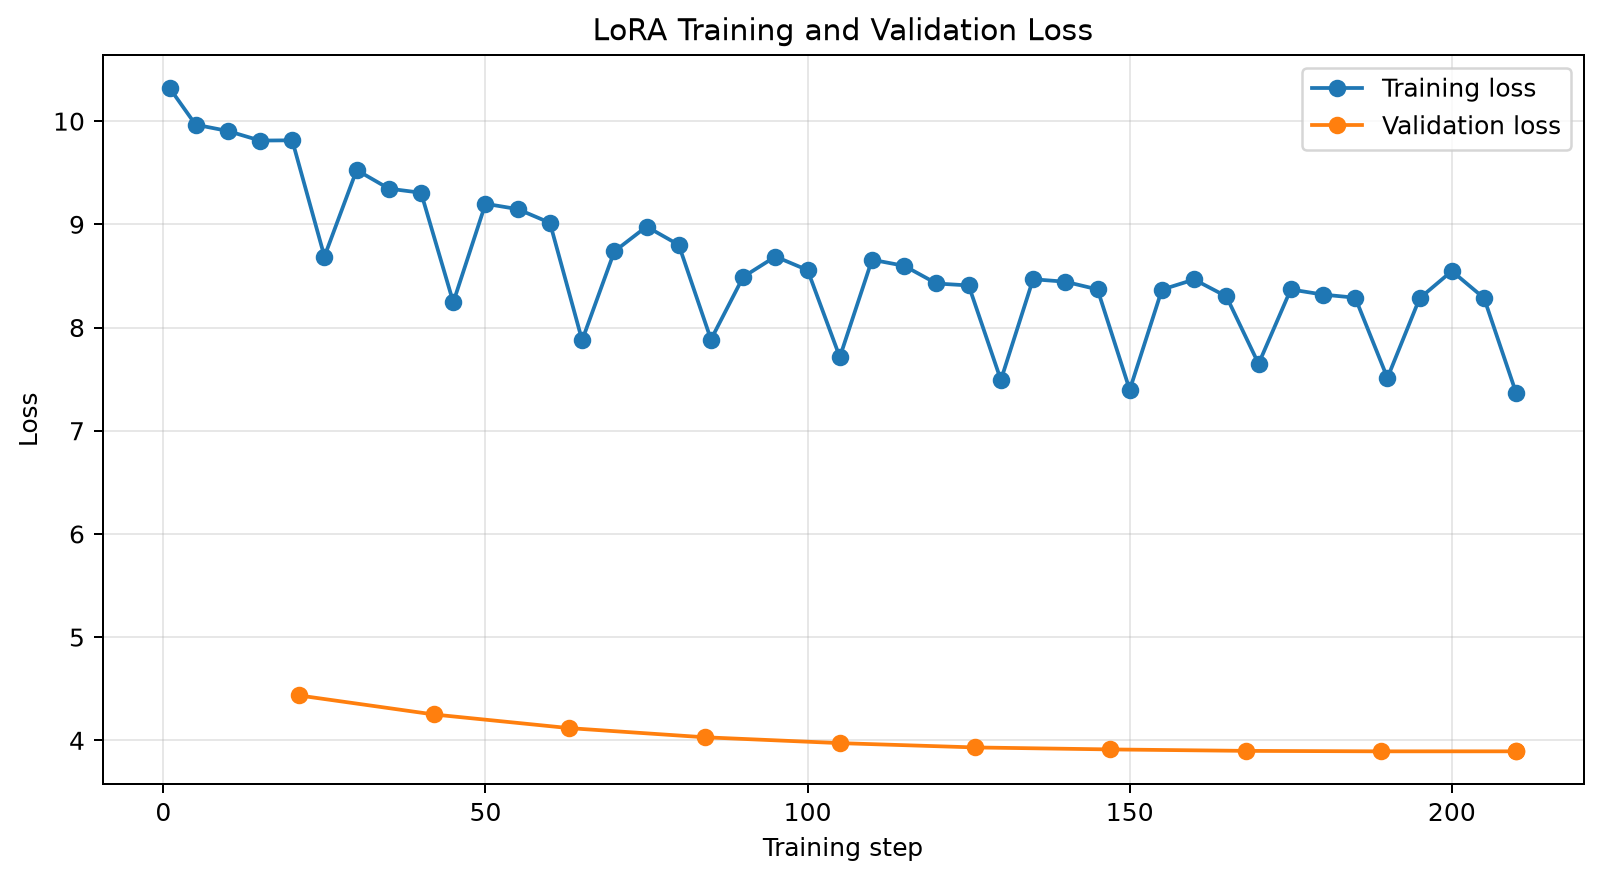

,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,4.435405,0.1152,364.528,26.038,1.0,21
1,4.250475,0.0900,466.696,33.335,2.0,42
2,4.118366,0.1011,415.327,29.666,3.0,63
3,4.029849,0.1003,418.725,29.909,4.0,84
4,3.972950,0.1015,413.707,29.551,5.0,105
5,3.931179,0.0835,503.115,35.937,6.0,126
6,3.911936,0.0873,481.020,34.359,7.0,147
7,3.897895,0.0909,461.808,32.986,8.0,168
8,3.893341,0.1103,380.741,27.196,9.0,189
9,3.893474,0.0872,481.544,34.396,10.0,210


In [9]:
from src.experiment_utils import load_json

history = load_json(RUN_DIR / 'training_log_history.json', default=[])
TRAINING_CURVE = PROJECT_DIR / 'outputs' / 'training_curve.png'
plot_training_history(history, TRAINING_CURVE)

from IPython.display import Image, display

display(Image(filename=str(TRAINING_CURVE)))

eval_rows = [item for item in history if 'eval_loss' in item]
display(pd.DataFrame(eval_rows))

## 8. Evaluate the base model and LoRA adapter on the same held-out prompts

The evaluation is deterministic (`do_sample=False`, four-beam search) and runs the base model and LoRA adapter separately to avoid GPU-memory overlap.

The resulting metrics are saved under `outputs/portfolio_experiment/`.

In [10]:
from src.advanced_evaluation import EvaluationConfig, run_base_vs_lora_evaluation

EVAL_OUTPUT_DIR = PROJECT_DIR / config['evaluation']['output_dir']
eval_config = EvaluationConfig(
    max_source_length=int(config['evaluation']['max_source_length']),
    max_target_length=int(config['evaluation']['max_target_length']),
    max_new_tokens=int(config['evaluation']['max_new_tokens']),
    num_beams=int(config['evaluation']['num_beams']),
    repetition_penalty=float(config['evaluation']['repetition_penalty']),
    batch_size_loss=int(config['evaluation']['batch_size_loss']),
    seed=SEED,
    bertscore_model_type=str(config['evaluation']['bertscore_model_type']),
    embedding_model_id=str(config['evaluation']['embedding_model_id']),
    bootstrap_samples=int(config['evaluation']['bootstrap_samples']),
    confidence_level=float(config['evaluation']['confidence_level']),
    low_reference_support_threshold=float(config['evaluation']['low_reference_support_threshold']),
)

MODEL_METRICS = run_base_vs_lora_evaluation(
    base_model_id=config['model']['base_model_id'],
    adapter_path=ADAPTER_PATH,
    evaluation_path=PROJECT_DIR / config['data']['evaluation_path'],
    output_dir=EVAL_OUTPUT_DIR,
    config=eval_config,
)

print('Evaluation complete:', EVAL_OUTPUT_DIR)
print(json.dumps(MODEL_METRICS['comparison'], indent=2))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | Details
------------------------+------------+--------
vocab_layer_norm.bias   | UNEXPECTED |        
vocab_transform.weight  | UNEXPECTED |        
vocab_projector.bias    | UNEXPECTED |        
vocab_transform.bias    | UNEXPECTED |        
vocab_layer_norm.weight | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluation complete: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\05-instruction-tuned-domain-llm\outputs\portfolio_experiment
{
  "status": "completed",
  "paired_examples": 36,
  "metrics": {
    "bertscore_f1": {
      "mean_delta": 0.04766889909903208,
      "median_delta": 0.032231926918029785,
      "ci_low": 0.02351174031694731,
      "ci_high": 0.07413784501453241,
      "n": 36,
      "win_rate": 0.7222222222222222,
      "tie_rate": 0.0,
      "loss_rate": 0.2777777777777778,
      "wilcoxon_p_value": 0.0014461304526776075
    },
    "rougeL": {
      "mean_delta": 0.1014152160834881,
      "median_delta": 0.08054840830994656,
      "ci_low": 0.07388298006096763,
      "ci_high": 0.13136249469663622,
      "n": 36,
      "win_rate": 0.9166666666666666,
      "tie_rate": 0.0,
      "loss_rate": 0.08333333333333333,
      "wilcoxon_p_value": 1.5599653124809265e-08
    },
    "semantic_relevance": {
      "mean_delta": 0.29762486989299

## 9. Review the base-versus-LoRA scorecard

In [11]:
base = MODEL_METRICS['base_model']
lora = MODEL_METRICS['lora_model']

scorecard = pd.DataFrame([
    {
        'Model': 'Base FLAN-T5-small',
        'Held-out loss': base['heldout_loss'],
        'Perplexity': base['perplexity'],
        'BERTScore F1': base['mean_bertscore_f1'],
        'ROUGE-L': base['mean_rougeL'],
        'Semantic relevance': base['mean_semantic_relevance'],
        'Instruction adherence': base['mean_adherence_score'],
        'Hallucination-risk flag rate': base['hallucination_risk_flag_rate'],
        'Mean latency seconds': base['mean_latency_seconds'],
        'Tokens/second': base['mean_tokens_per_second'],
    },
    {
        'Model': 'LoRA instruction-tuned model',
        'Held-out loss': lora['heldout_loss'],
        'Perplexity': lora['perplexity'],
        'BERTScore F1': lora['mean_bertscore_f1'],
        'ROUGE-L': lora['mean_rougeL'],
        'Semantic relevance': lora['mean_semantic_relevance'],
        'Instruction adherence': lora['mean_adherence_score'],
        'Hallucination-risk flag rate': lora['hallucination_risk_flag_rate'],
        'Mean latency seconds': lora['mean_latency_seconds'],
        'Tokens/second': lora['mean_tokens_per_second'],
    },
])
display(scorecard.round(4))

comparison = MODEL_METRICS['comparison']['metrics']
paired = pd.DataFrame([
    {
        'Metric': metric,
        'Mean paired improvement': values['mean_delta'],
        '95% CI low': values['ci_low'],
        '95% CI high': values['ci_high'],
        'LoRA win rate': values['win_rate'],
        'Wilcoxon p-value': values.get('wilcoxon_p_value'),
    }
    for metric, values in comparison.items()
])
display(paired.round(4))

,Model,Held-out loss,Perplexity,BERTScore F1,ROUGE-L,Semantic relevance,Instruction adherence,Hallucination-risk flag rate,Mean latency seconds,Tokens/second
0,Base FLAN-T5-small,4.6528,104.8759,0.6928,0.0423,0.2947,0.4710,0.7500,0.2345,70.0710
1,LoRA instruction-tuned model,3.9201,50.4074,0.7404,0.1438,0.5923,0.8452,0.1944,1.2847,60.8139


,Metric,Mean paired improvement,95% CI low,95% CI high,LoRA win rate,Wilcoxon p-value
0,bertscore_f1,0.0477,0.0235,0.0741,0.7222,0.0014
1,rougeL,0.1014,0.0739,0.1314,0.9167,0.0000
2,semantic_relevance,0.2976,0.2110,0.3847,0.7778,0.0000
3,adherence_score,0.3742,0.3329,0.4172,1.0000,0.0000
4,reference_support_score,0.2883,0.2033,0.3741,0.8333,0.0000
5,tokens_per_second,-9.2571,-16.2593,-1.4615,0.3056,0.0272
6,latency_seconds,-1.0502,-1.3400,-0.7974,0.0000,NaN


## 10. Review category-level performance and per-example evidence

In [12]:
category_metrics = pd.read_csv(EVAL_OUTPUT_DIR / 'category_metrics.csv')
paired_examples = pd.read_csv(EVAL_OUTPUT_DIR / 'base_vs_lora_per_example.csv')

display(category_metrics)

display_columns = [
    'id', 'category', 'topic', 'instruction',
    'generated_answer_base', 'generated_answer_lora',
    'delta_bertscore_f1', 'delta_semantic_relevance', 'delta_adherence_score',
]
display(
    paired_examples.sort_values('delta_bertscore_f1', ascending=False)[display_columns].head(15)
)

,model,category,bertscore_f1,bertscore_f1.1,bertscore_f1.2,rougeL,rougeL.1,rougeL.2,semantic_relevance,semantic_relevance.1,semantic_relevance.2,adherence_score,adherence_score.1,adherence_score.2,reference_support_score,reference_support_score.1,reference_support_score.2,latency_seconds,latency_seconds.1,latency_seconds.2
0,NaN,NaN,mean,std,count,mean,std,count,mean,std,count,mean,std,count,mean,std,count,mean,std,count
1,base_model,algorithm_comparison,0.653484,0.055536,2,0.018519,0.026189,2,0.123679,0.03092,2,0.19,0.028284,2,0.091787,0.020585,2,0.149494,0.026625,2
2,base_model,code_example,0.665234,NaN,1,0.037736,NaN,1,0.120271,NaN,1,0.21,NaN,1,0.138854,NaN,1,0.146316,NaN,1
3,base_model,concept_explanation,0.725696,0.040195,9,0.070873,0.041789,9,0.379266,0.315308,9,0.520926,0.124145,9,0.362141,0.295374,9,0.226603,0.144922,9
4,base_model,example_generation,0.706455,0.029124,7,0.05382,0.033887,7,0.245496,0.178777,7,0.690714,0.043821,7,0.209336,0.154851,7,0.399514,0.147488,7
5,base_model,interview_answer,0.608177,0.006795,7,0.0,0.0,7,0.109055,0.05132,7,0.42,0.0,7,0.087833,0.057862,7,0.178947,0.042485,7
6,base_model,metric_explanation,0.725094,0.037067,4,0.03918,0.03344,4,0.417458,0.230746,4,0.29375,0.145795,4,0.348652,0.187736,4,0.226596,0.038029,4
7,base_model,quality_analytics,0.754873,0.036911,2,0.053605,0.027043,2,0.54766,0.265587,2,0.565,0.148492,2,0.488894,0.232908,2,0.172085,0.050664,2
8,base_model,responsible_ai,0.739415,NaN,1,0.072727,NaN,1,0.453791,NaN,1,0.685,NaN,1,0.353383,NaN,1,0.185782,NaN,1
9,base_model,workflow_explanation,0.69469,0.059363,3,0.032695,0.028542,3,0.37556,0.220298,3,0.304167,0.126004,3,0.320976,0.15535,3,0.157203,0.083549,3


,id,category,topic,instruction,generated_answer_base,generated_answer_lora,delta_bertscore_f1,delta_semantic_relevance,delta_adherence_score
22,mlds-ext-e1bef5712e5d,interview_answer,recurrent neural network,Give an interview-style answer explaining recu...,ML/DS,An interview answer is: Recurrent neural netwo...,0.200626,0.538725,0.5300
23,mlds-ext-2f78f3c3e743,interview_answer,retrieval-augmented generation,Give an interview-style answer explaining retr...,ML/DS,An interview answer is: retrieval-augmented ge...,0.192577,0.496571,0.3925
19,mlds-ext-5206f35df89f,interview_answer,class imbalance,Give an interview-style answer explaining clas...,ML/DS,A good interview answer is: Class imbalance is...,0.185112,0.579751,0.5050
20,mlds-ext-261a67980f43,interview_answer,model drift,Give an interview-style answer explaining mode...,ML/DS,An interview answer is: Model drift is a model...,0.172921,0.640086,0.2800
24,mlds-ext-ec9112efcbed,interview_answer,self-supervised learning,Give an interview-style answer explaining self...,ML/DS,An interview answer is: Self-supervised learni...,0.165034,0.573951,0.3925
25,mlds-ext-b61bc960dfec,interview_answer,semantic search,Give an interview-style answer explaining sema...,ML/DS,A good interview answer is: semantic search is...,0.164402,0.641175,0.3925
21,mlds-ext-0130527214a7,interview_answer,quantization,Give an interview-style answer explaining quan...,ML/DS,An interview answer is: Quantization is a meas...,0.156099,0.356618,0.2800
1,mlds-ext-194e4c01718a,algorithm_comparison,MAE vs RMSE,Compare MAE and RMSE.,ML/DS,MAE and RMSE are a two-dimensional model that ...,0.129372,0.550799,0.6800
33,mlds-ext-746144a78be4,workflow_explanation,error-analysis,What should an error analysis include?,ML/DS,Error analysis should be able to identify a sp...,0.102981,0.420256,0.5300
26,mlds-ext-e9c769888e6b,metric_explanation,macro-weighted-f1,Explain macro F1 and weighted F1.,Describe the ML/DS and ML/DS.,macro F1 weighted F1 weighted F1 weighted F1 w...,0.082471,0.455117,0.5300


## 11. Display generated evaluation plots

base_vs_lora_metric_comparison.png


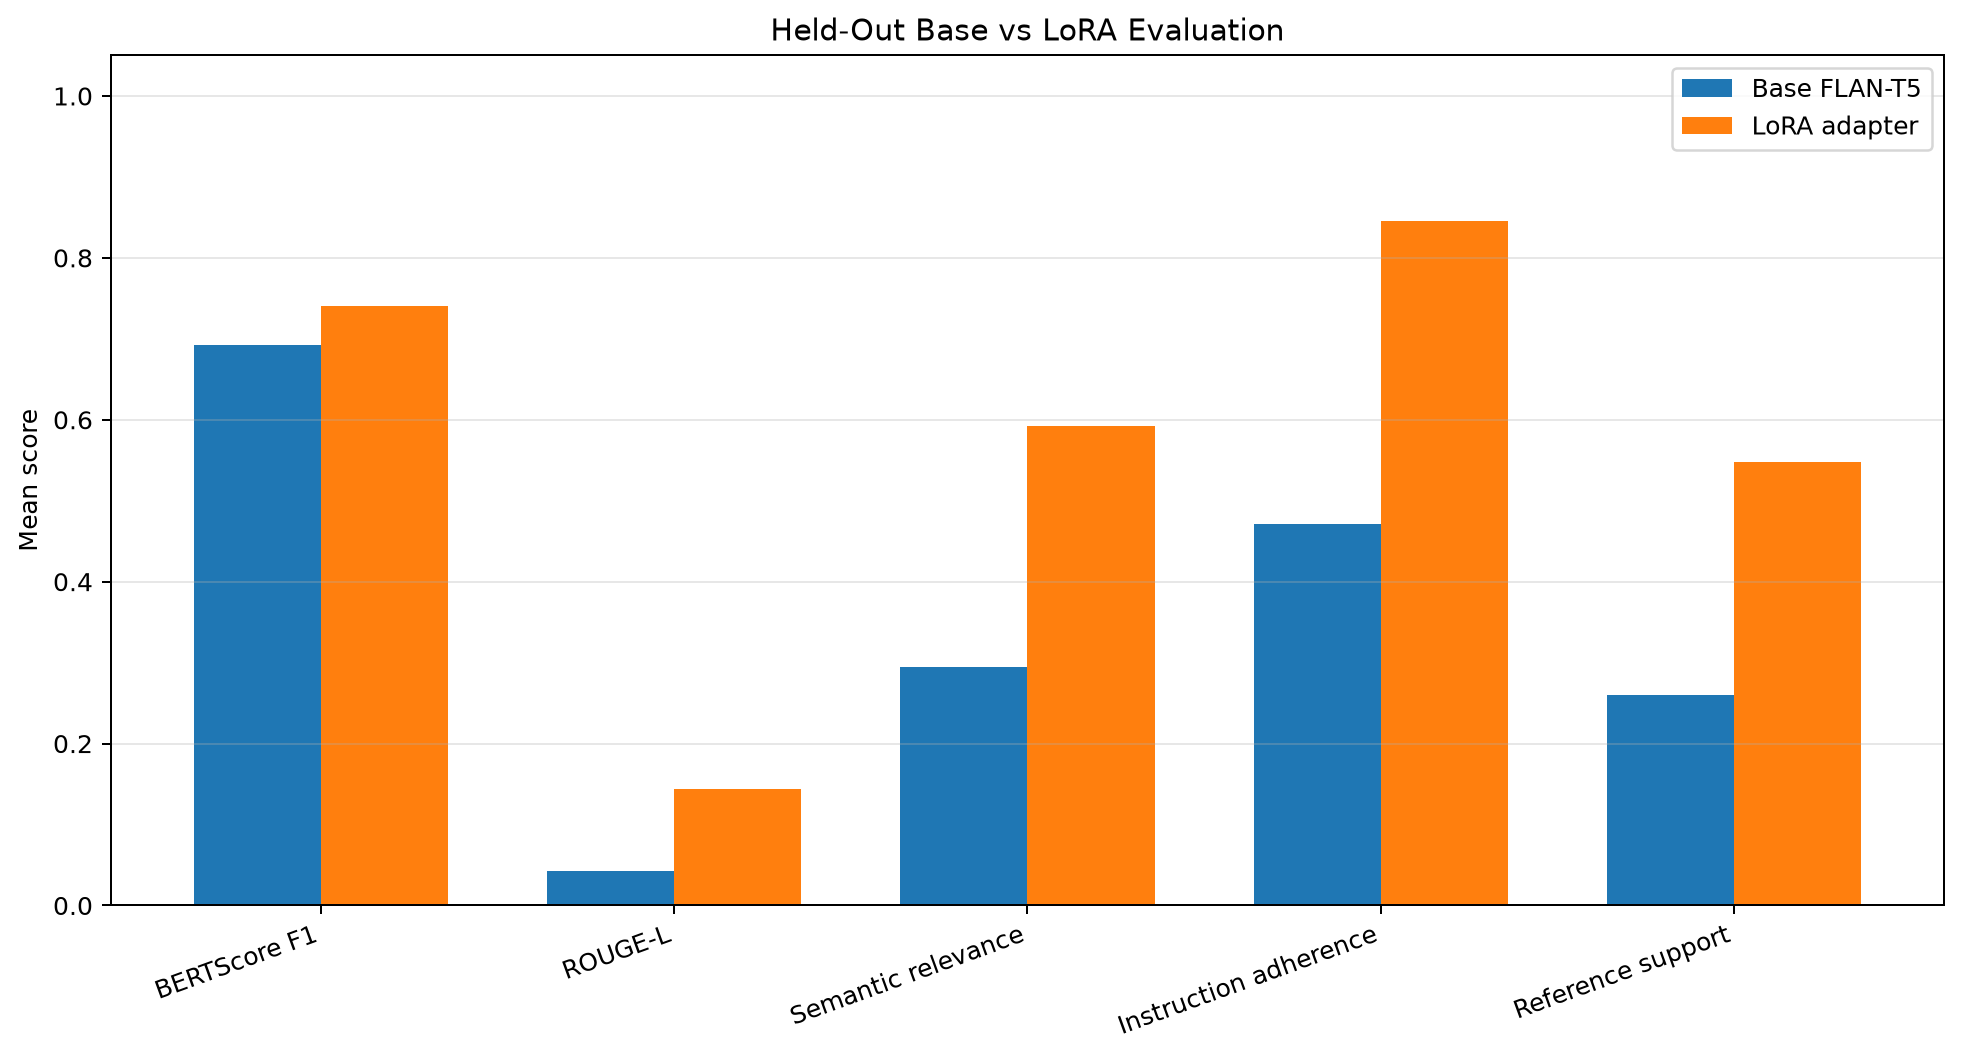

bertscore_improvement_by_category.png


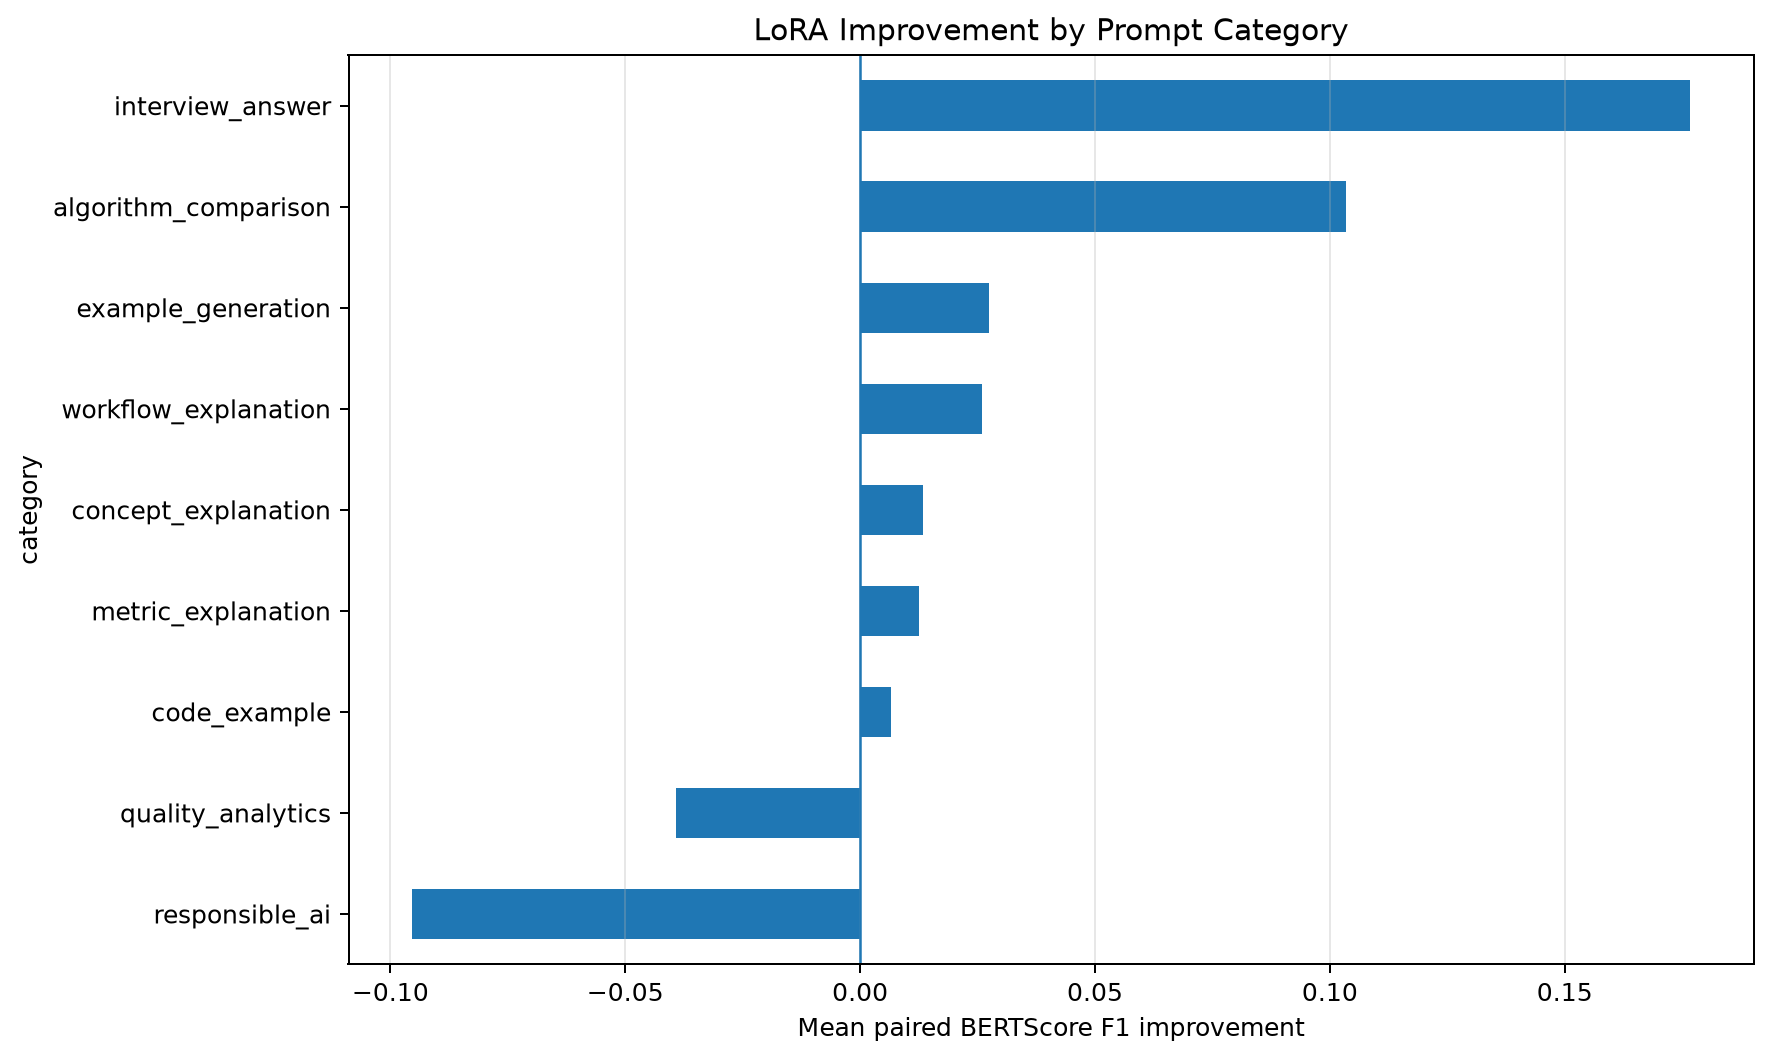

latency_comparison.png


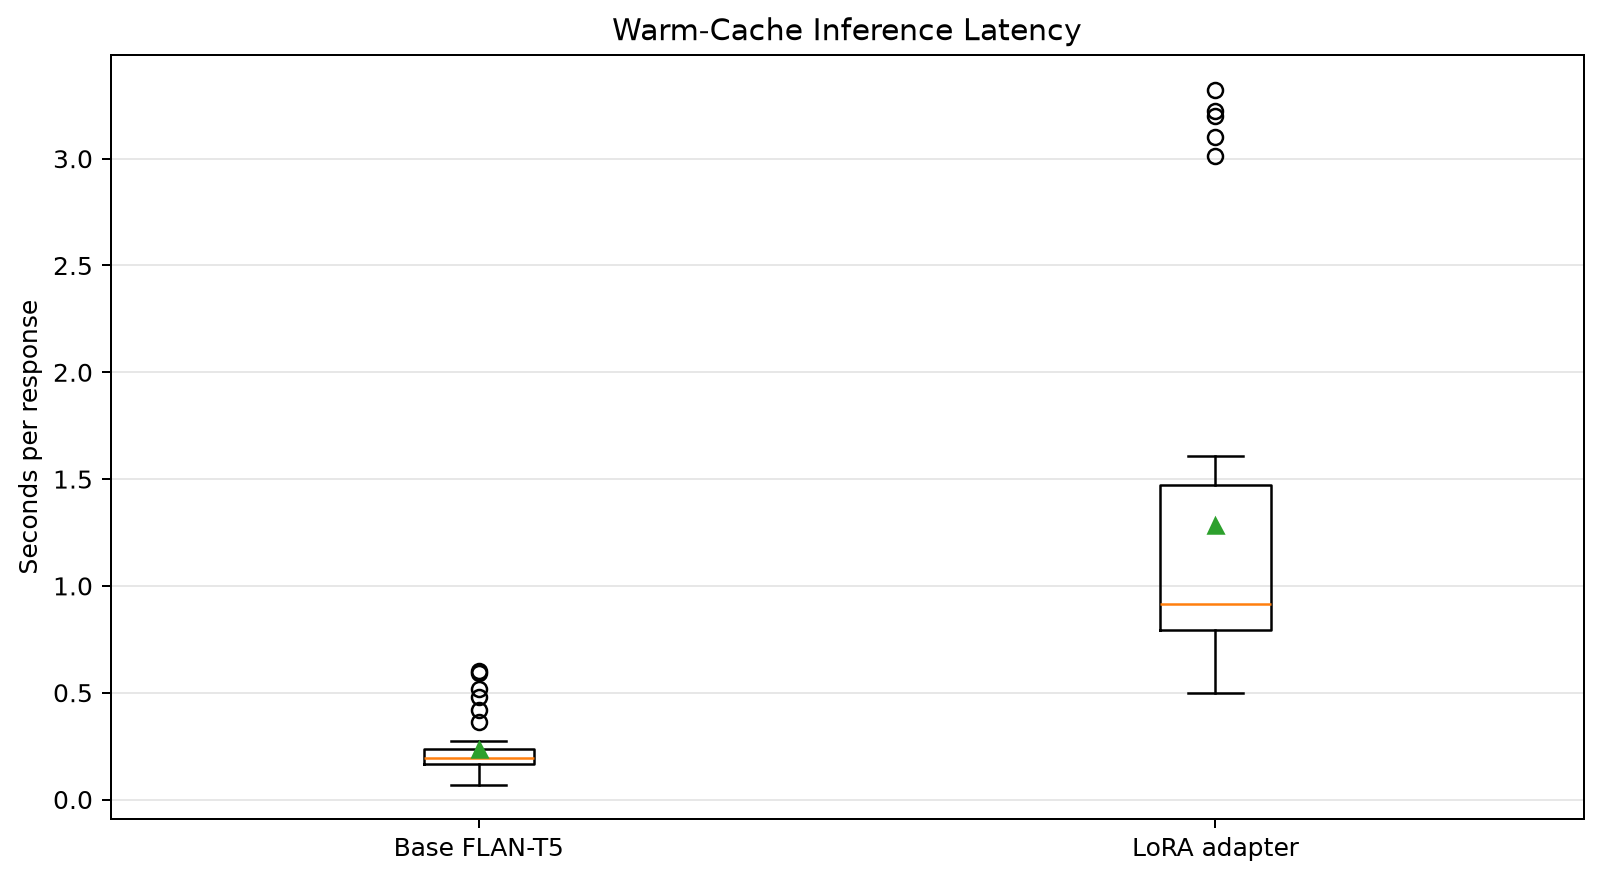

In [13]:
from IPython.display import Image, display

for filename in [
    'base_vs_lora_metric_comparison.png',
    'bertscore_improvement_by_category.png',
    'latency_comparison.png',
]:
    path = EVAL_OUTPUT_DIR / filename
    print(filename)
    display(Image(filename=str(path)))

## 12. Complete the manual factuality and quality review

Open `outputs/portfolio_experiment/manual_review_results.csv` in Excel or a spreadsheet editor. Score the sampled base and LoRA answers using the included 1-to-5 fields and mark hallucinations explicitly.

Recommended interpretation:

- **5:** correct, complete, relevant, and clear;
- **4:** correct with a minor omission;
- **3:** partly correct or noticeably incomplete;
- **2:** major error or misleading explanation;
- **1:** incorrect, unusable, or unsafe.

After completing the file, run the next cell to summarize the human review.

In [19]:
MANUAL_REVIEW_PATH = EVAL_OUTPUT_DIR / 'manual_review_results.csv'
manual_df = pd.read_csv(MANUAL_REVIEW_PATH)
manual_df.head()

,id,category,topic,instruction,reference_answer,generated_answer_base,generated_answer_lora,base_correctness_1_to_5,lora_correctness_1_to_5,base_relevance_1_to_5,lora_relevance_1_to_5,base_clarity_1_to_5,lora_clarity_1_to_5,preferred_model,hallucination_present_base,hallucination_present_lora,reviewer_notes
0,mlds-ext-9a3f3c0f955e,algorithm_comparison,accuracy and F1-score,Compare accuracy and F1-score.,Accuracy measures the overall proportion of co...,You are an educational ML and Data Science lea...,Accurate accuracy and F1-score is a measure of...,1,1,1,2,2,1,neither,no,yes,Base returned a system-style fragment. LoRA me...
1,mlds-ext-194e4c01718a,algorithm_comparison,MAE vs RMSE,Compare MAE and RMSE.,"MAE averages absolute errors, while RMSE squar...",ML/DS,MAE and RMSE are a two-dimensional model that ...,1,1,1,2,2,1,neither,no,yes,Base was a non-answer. LoRA incorrectly descri...
2,mlds-ext-04aabbbac1ba,code_example,LoRA configuration,Generate a small PEFT LoRA configuration for a...,"```python\nfrom peft import LoraConfig, TaskTy...",You are an educational ML and Data Science lea...,Small PEFT LoRA configuration for a T5 sequenc...,1,1,1,2,2,2,neither,no,no,Base returned an assistant-description fragmen...
3,mlds-ext-58d17c7da556,concept_explanation,quantization,Explain quantization in simple terms.,Quantization stores or computes model values w...,Use a ML/DS learning assistant. Use ML/DS lear...,Quantization is a measure of the size of a sam...,1,1,1,2,1,1,neither,no,yes,Base was unrelated. LoRA gave an incorrect def...
4,mlds-ext-cfc17cfc3f66,concept_explanation,retrieval-augmented generation,Explain retrieval-augmented generation in simp...,Retrieval-augmented generation retrieves relev...,Describe ML/DS as a learning assistant.,A retrieval-augmented generation is a model th...,1,1,1,2,2,1,neither,no,yes,Base merely restated the assistant role. LoRA ...


In [20]:
review_columns = [
    'base_correctness_1_to_5', 'lora_correctness_1_to_5',
    'base_relevance_1_to_5', 'lora_relevance_1_to_5',
    'base_clarity_1_to_5', 'lora_clarity_1_to_5',
]

completed = manual_df.dropna(subset=review_columns, how='any').copy()
if completed.empty:
    print('Manual review has not been completed yet. Fill the CSV and rerun this cell.')
else:
    for column in review_columns:
        completed[column] = pd.to_numeric(completed[column], errors='coerce')
    human_summary = {
        'status': 'completed',
        'reviewed_examples': int(len(completed)),
        'base_correctness_mean': float(completed['base_correctness_1_to_5'].mean()),
        'lora_correctness_mean': float(completed['lora_correctness_1_to_5'].mean()),
        'base_relevance_mean': float(completed['base_relevance_1_to_5'].mean()),
        'lora_relevance_mean': float(completed['lora_relevance_1_to_5'].mean()),
        'base_clarity_mean': float(completed['base_clarity_1_to_5'].mean()),
        'lora_clarity_mean': float(completed['lora_clarity_1_to_5'].mean()),
        'preferred_model_counts': completed['preferred_model'].value_counts(dropna=False).to_dict(),
    }
    save_json(human_summary, EVAL_OUTPUT_DIR / 'manual_review_summary.json')
    display(pd.DataFrame([human_summary]))

,status,reviewed_examples,base_correctness_mean,lora_correctness_mean,base_relevance_mean,lora_relevance_mean,base_clarity_mean,lora_clarity_mean,preferred_model_counts
0,completed,24,1.0,1.125,1.25,2.083333,1.541667,1.333333,"{'neither': 22, 'lora': 2}"


## 13. Synchronize real metrics with the Static Space and README snippet

In [21]:
subprocess.run(
    [
        sys.executable,
        'scripts/sync_evaluation_to_web.py',
        '--metrics', str(EVAL_OUTPUT_DIR / 'model_metrics.json'),
        '--dataset-stats', str(PROJECT_DIR / 'outputs' / 'extended_dataset_statistics.json'),
    ],
    check=True,
)

print((PROJECT_DIR / 'outputs' / 'README_RESULTS_SNIPPET.md').read_text(encoding='utf-8'))

## Executed experiment results

The final run used **401** public-safe instruction examples with topic-grouped splits and evaluated **36** held-out prompts.

| Metric | Base FLAN-T5 | LoRA adapter |
|---|---:|---:|
| Held-out loss | 4.6528 | 3.9201 |
| Perplexity | 104.8759 | 50.4074 |
| BERTScore F1 | 0.6928 | 0.7404 |
| ROUGE-L | 0.0423 | 0.1438 |
| Semantic relevance | 0.2947 | 0.5923 |
| Instruction adherence | 0.4710 | 0.8452 |
| Automated hallucination-risk flag rate | 0.7500 | 0.1944 |
| Mean warm-cache latency, seconds | 0.2345 | 1.2847 |

Paired BERTScore F1 improvement: **0.0477**, with a 95% bootstrap interval of **[0.0235, 0.0741]**.

> BERTScore, ROUGE, embedding similarity, and heuristic risk flags do not prove factual correctness. See the per-example CSV files and complete the manual review template.


## 14. Optional: upload the trained LoRA adapter to Hugging Face

Create a **model repository**, not a Space, for the adapter. Authenticate with `hf auth login` in a terminal, or use `huggingface_hub.login()` interactively. Never paste a token into a notebook cell that will be committed to GitHub.

In [ ]:
PUSH_ADAPTER_TO_HUB = False
HF_ADAPTER_REPO_ID = 'unit-mole/flan-t5-small-ml-ds-assistant-lora'

if PUSH_ADAPTER_TO_HUB:
    from huggingface_hub import HfApi
    from peft import PeftModel
    from transformers import AutoTokenizer

    api = HfApi()
    api.create_repo(HF_ADAPTER_REPO_ID, repo_type='model', exist_ok=True)
    api.upload_folder(
        repo_id=HF_ADAPTER_REPO_ID,
        repo_type='model',
        folder_path=str(ADAPTER_PATH),
        commit_message='Upload Project 05 LoRA adapter and tokenizer',
    )
    api.upload_file(
        repo_id=HF_ADAPTER_REPO_ID,
        repo_type='model',
        path_or_fileobj=str(PROJECT_DIR / 'MODEL_CARD.md'),
        path_in_repo='README.md',
        commit_message='Add model card',
    )
    print('Uploaded:', HF_ADAPTER_REPO_ID)
else:
    print('Adapter upload skipped. Set PUSH_ADAPTER_TO_HUB=True after authenticating.')

## 15. Optional: merge and export the custom model for the Static Space

After the adapter metrics and manual review are acceptable:

```bash
python scripts/merge_lora_adapter.py --adapter-path models/experiments/<run-id>/adapter
python scripts/export_merged_model_to_onnx.py
python scripts/publish_browser_model.py
```

Update the Static Space model ID only after the merged ONNX repository has been successfully uploaded and tested. Until then, keep the interface honest about using the base browser model.

## 16. Final generated artifacts

After a successful run, commit the following evidence:

```text
models/experiments/<run-id>/adapter/         # use Hugging Face Hub or Git LFS when appropriate
outputs/hardware_environment.json
outputs/extended_dataset_statistics.json
outputs/extended_dataset_validation_report.json
outputs/training_curve.png
outputs/portfolio_experiment/model_metrics.json
outputs/portfolio_experiment/base_model_metrics.json
outputs/portfolio_experiment/lora_model_metrics.json
outputs/portfolio_experiment/base_vs_lora_comparison.json
outputs/portfolio_experiment/base_vs_lora_per_example.csv
outputs/portfolio_experiment/category_metrics.csv
outputs/portfolio_experiment/generated_response_examples.csv
outputs/portfolio_experiment/manual_review_results.csv
outputs/portfolio_experiment/manual_review_summary.json
outputs/portfolio_experiment/hallucination_analysis.md
outputs/portfolio_experiment/before_after_finetuning_examples.md
outputs/portfolio_experiment/*.png
outputs/README_RESULTS_SNIPPET.md
web/public/evaluation-summary.json
```

Do not commit private Hugging Face tokens, local virtual environments, caches, or very large merged model weights to ordinary Git history.

## 17. Git commands after the experiment

Run from the main `transformer-projects` repository folder:

```bash
git add "05-instruction-tuned-domain-llm" ".github/workflows/05-instruction-tuned-domain-llm.yml"
git commit -m "Add trained LoRA model evaluation results for Project 05"
git push origin main
```

Before committing, run `git status` and verify that only Project 05 and its dedicated workflow are staged.